In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob, os
from collections import Counter

In [7]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
sudf = pd.read_csv('../data/Table_S1.csv')
sudf = sudf[['sample','cells_or_tissue_frac']].copy()


dfs = []
for i, r in cdf.iterrows():
    ch = r.dataset
    if not os.path.isfile(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt'):
        continue
        
    bdf = pd.read_csv(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt', sep='\t')
    dfs.append(bdf)
df = pd.concat(dfs)
cdf = cdf.merge(df, left_on='sample', right_on='sample', how='left')
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')
cdf = cdf.merge(sudf, left_on='sample', right_on='sample', how='left')
cdf['L_norm'] = cdf['nb_lib_L'] / cdf['cells_or_tissue_frac']

In [8]:
cdf['group'].value_counts()

group
PBMC_scrna         36
visium_hd          24
OvaryCA_CD45p      20
OvaryCA_CD45m      19
Heart              13
PBMC_scrna_flex    11
visium              9
Brain               7
Colon               6
Melanoma            4
Name: count, dtype: int64

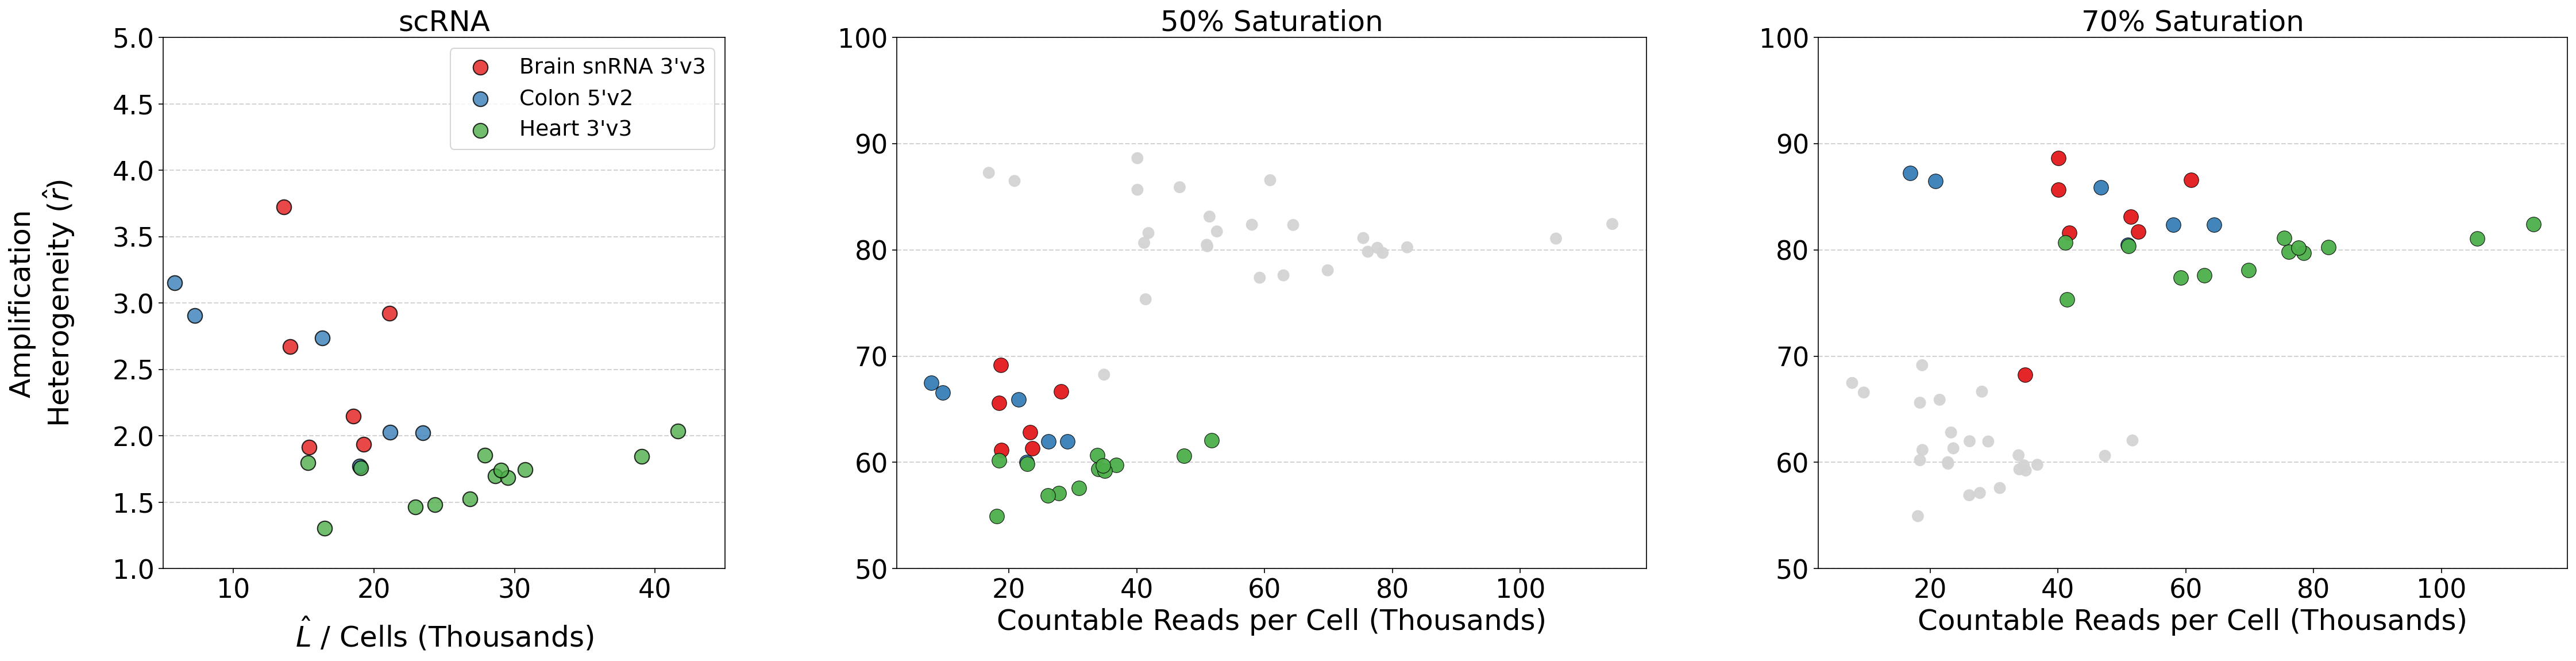

In [9]:
groups = ['Brain', 'Colon', 'Heart']
labs = ['Brain snRNA', 'Colon scRNA', 'Heart scRNA']


fig, axs = pl.figax(1, 3, h=8, w=12, width_ratios=[3, 4, 4])
fig.subplots_adjust(wspace=0.25, hspace=0.4)
sats = [50, 70]

for c, g, l in zip(plt.cm.Set1.colors, groups, labs):
    vdf = cdf[cdf['group'] == g].copy()    
    m = 'o'
    seen = set()
    for s in vdf.itertuples():
        if np.isnan(s.ztnb_phat):
            continue
        title = s.title
    
        lab = '_'
        if title not in seen:
            seen.add(title)
            lab = title
        axs[0].scatter(s.L_norm/1000, s.ztnb_rhat, s=150, color=c, label=lab, edgecolor='k', lw=1, alpha=0.8, marker=m)
    
    
        lab = '_'
        if title not in seen:
            seen.add(title)
            lab = title
        ff = fit.NBLibFit(rhat=s.ztnb_rhat, phat=s.ztnb_phat, L=s.nb_lib_L)
        reads = ff.reads_for_saturation(sats)
        nreads = (reads / s.cells_or_tissue_frac) / 1000
    
        recs = ff.predict_recovery(reads) 
        
    
        axs[1].scatter(nreads[0], recs[0], color=c, edgecolor='k', lw=0.5, s=150, alpha=0.95, marker=m, zorder=5, label=lab)
        axs[2].scatter(nreads[0], recs[0], color='lightgray', edgecolor='none', lw=0.5, s=100, alpha=0.95, marker=m, zorder=4)
    
        axs[2].scatter(nreads[1], recs[1], color=c, edgecolor='k', lw=0.5, s=150, alpha=0.95, marker=m, zorder=5)
        axs[1].scatter(nreads[1], recs[1], color='lightgray', edgecolor='none', lw=0.5, s=100, alpha=0.95, marker=m, zorder=4)
    
for ax in axs:
    #ax.set_xscale('log')
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=22)
    ax.tick_params(axis='both', which='both', length=4)
axs[1].set_ylim(50, 100)
axs[2].set_ylim(50, 100)
axs[0].set_ylim(1, 5)
axs[0].set_xlim(5, 45)
#axs[1].set_xlim(0.8 * 10**3, 10**5)
#axs[2].set_xlim(0.8 * 10**3, 10**5)
axs[0].set_title('scRNA', fontsize=24)
axs[1].set_xlabel('Countable Reads per Cell (Thousands)', fontsize=24)
axs[2].set_xlabel('Countable Reads per Cell (Thousands)', fontsize=24)

#axs[0].set_xscale('log')
axs[0].set_xlabel('$\\hat{L}$ / Cells (Thousands)', fontsize=24, labelpad=10)
axs[0].set_ylabel('Amplification\nHeterogeneity ($\\hat{r}$)', fontsize=24, labelpad=30)
axs[1].set_title('50% Saturation', fontsize=24)
axs[2].set_title('70% Saturation', fontsize=24)
axs[0].legend(loc = 'best', fontsize=18)
fig.savefig('../Figures/Figure S6 scRNA.svg', bbox_inches='tight')

rec 50 61.75657550171512 70.10767875972319
rec 70 82.15131784642729 89.40515323088252
cost 50 195.9447636554388 2708.125850898045
cost 70 420.7103894286505 5996.521909757737
real cost 50 116.55816152831339 1012.8537361223384
real cost 70 255.73322797047283 2245.57111347106


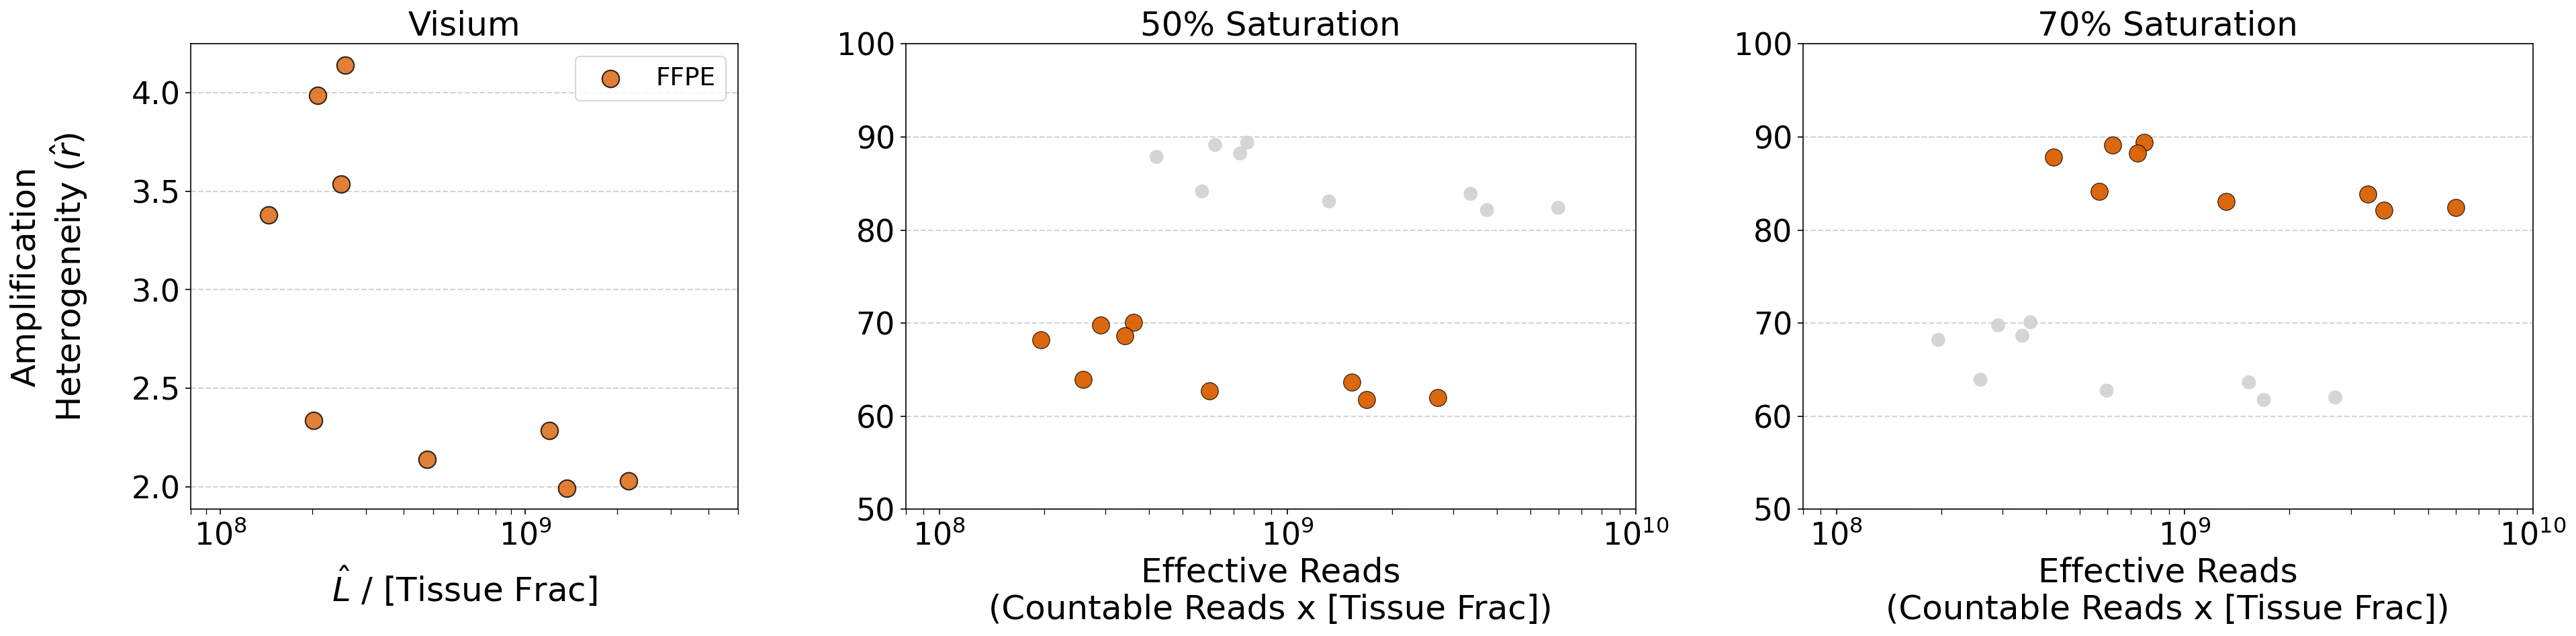

In [10]:
vdf = cdf[cdf['group'] == 'visium']
fig, axs = pl.figax(1, 3, h=6, w=10, width_ratios=[3, 4, 4])
fig.subplots_adjust(wspace=0.25, hspace=0.3)
seen = set()
frecs = {50:[], 70:[]}
fcost = {50:[], 70:[]}
freal = {50:[], 70:[]}

for s in vdf.itertuples():
    if np.isnan(s.ztnb_phat):
        continue
    title = s.subgroup_title

    lab = '_'
    if title not in seen:
        seen.add(title)
        lab = title
    axs[0].scatter(s.L_norm, s.ztnb_rhat, s=150, color=s.color, label=lab, edgecolor='k', lw=1, alpha=0.8, marker='o')


    lab = '_'
    if title not in seen:
        seen.add(title)
        lab = title
    ff = fit.NBLibFit(rhat=s.ztnb_rhat, phat=s.ztnb_phat, L=s.nb_lib_L)
    reads = ff.reads_for_saturation(sats)
    nreads = (reads / s.cells_or_tissue_frac) 

    recs = ff.predict_recovery(reads)
    frecs[50].append(recs[0])
    frecs[70].append(recs[1])
    fcost[50].append(nreads[0])
    fcost[70].append(nreads[1])
    freal[50].append(reads[0])
    freal[70].append(reads[1])
    axs[1].scatter(nreads[0], recs[0], color=s.color, edgecolor='k', lw=0.5, s=150, alpha=0.95, marker='o', zorder=5, label=lab)
    axs[2].scatter(nreads[0], recs[0], color='lightgray', edgecolor='none', lw=0.5, s=100, alpha=0.95, marker='o', zorder=4)

    axs[2].scatter(nreads[1], recs[1], color=s.color, edgecolor='k', lw=0.5, s=150, alpha=0.95, marker='o', zorder=5)
    axs[1].scatter(nreads[1], recs[1], color='lightgray', edgecolor='none', lw=0.5, s=100, alpha=0.95, marker='o', zorder=4)
print('rec', 50, min(frecs[50]), max(frecs[50]))
print('rec', 70, min(frecs[70]), max(frecs[70]))

print('cost', 50, min(fcost[50])/1e6, max(fcost[50])/1e6)
print('cost', 70, min(fcost[70])/1e6, max(fcost[70])/1e6)

print('real cost', 50, min(freal[50])/1e6, max(freal[50])/1e6)
print('real cost', 70, min(freal[70])/1e6, max(freal[70])/1e6)
for ax in axs:

    ax.set_xscale('log')
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=22)
    ax.tick_params(axis='both', which='both', length=4)
axs[1].set_ylim(50, 100)
axs[2].set_ylim(50, 100)
axs[1].set_xlabel('Effective Reads\n(Countable Reads x [Tissue Frac])', fontsize=24)
axs[2].set_xlabel('Effective Reads\n(Countable Reads x [Tissue Frac])', fontsize=24)

axs[0].set_xlim(0.8*10**8, 5*10**9)
axs[1].set_xlim(0.8*10**8, 10**10)
axs[2].set_xlim(0.8*10**8, 10**10)

axs[0].set_xscale('log')
axs[0].set_xlabel('$\\hat{L}$ / [Tissue Frac]', fontsize=24, labelpad=10)
axs[0].set_ylabel('Amplification\nHeterogeneity ($\\hat{r}$)', fontsize=24, labelpad=30)
axs[1].set_title('50% Saturation', fontsize=24)
axs[2].set_title('70% Saturation', fontsize=24)
axs[0].set_title('Visium', fontsize=24)
axs[0].legend(loc = 'upper right', fontsize=18)
fig.savefig('../Figures/Figure S6 Visium.svg', bbox_inches='tight')